# Brualdi — Introductory Combinatorics
## Chapter 1: What is Combinatorics?

**Textbook:** Introductory Combinatorics, 5th Edition — Richard A. Brualdi

---

## Progress

| Section | Topic | Status |
|---------|-------|--------|
| §1.1 | Perfect Covers of a Chessboard | Notes |
| §1.2 | Magic Squares | Notes |
| Exercises | Chapter 1 | Skipping for now |

---

## What is Combinatorics?

Combinatorics is the mathematics of counting, arranging, and structuring discrete objects.

Unlike calculus, which deals with continuous change, combinatorics asks questions like:

- **Existence:** Does a certain arrangement even exist?
- **Counting:** If it does, how many such arrangements are there?
- **Optimisation:** Which arrangement is best by some measure?

§1.1 is a perfect opening because it hits all three questions at once using a completely concrete object: dominoes on a chessboard.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 100

# ── Colour palette ──────────────────────────────────────────────────
LIGHT   = '#F0D9B5'   # light square (chess.com style)
DARK    = '#B58863'   # dark square
EDGE    = '#444444'
PALETTE = ['#E74C3C', '#3498DB', '#F1C40F', '#2ECC71', '#9B59B6', '#E67E22']
BCOLORS = ['#E74C3C', '#3498DB', '#F1C40F', '#2ECC71']   # for b=4 coloring

# ── Shared drawing helpers ───────────────────────────────────────────
def draw_board(ax, rows=8, cols=8, removed=None, alpha=0.9):
    """Draw an m×n chessboard. removed = set of (row, col) tuples to skip."""
    removed = set(removed or [])
    for r in range(rows):
        for c in range(cols):
            if (r, c) in removed:
                continue
            fc = LIGHT if (r + c) % 2 == 0 else DARK
            ax.add_patch(patches.Rectangle(
                (c, rows - 1 - r), 1, 1, lw=0.5, ec=EDGE, fc=fc, alpha=alpha))
    ax.set_xlim(0, cols)
    ax.set_ylim(0, rows)
    ax.set_aspect('equal')
    ax.axis('off')

def domino_h(ax, r, c, rows, color, alpha=0.85):
    """Horizontal domino covering (row r, col c) and (row r, col c+1)."""
    ax.add_patch(patches.FancyBboxPatch(
        (c + .06, rows - 1 - r + .06), 1.88, .88,
        boxstyle='round,pad=.04', lw=1.5, ec='white', fc=color, alpha=alpha))

def domino_v(ax, r, c, rows, color, alpha=0.85):
    """Vertical domino covering (row r, col c) and (row r+1, col c)."""
    ax.add_patch(patches.FancyBboxPatch(
        (c + .06, rows - 2 - r + .06), .88, 1.88,
        boxstyle='round,pad=.04', lw=1.5, ec='white', fc=color, alpha=alpha))

print("Helpers loaded. Run cells in order.")


---

## §1.1 Perfect Covers of a Chessboard

### The Problem

An ordinary 8×8 chessboard has 64 squares. A **domino** is a 1×2 piece that covers exactly two adjacent squares. Can you tile the whole board perfectly using 32 dominoes — no overlap, no gaps?

**Answer: Yes.** The two simplest ways:

1. **Row-by-row**: lay 4 horizontal dominoes in each of the 8 rows → 32 dominoes.
2. **Column-by-column**: lay 4 vertical dominoes in each of the 8 columns → 32 dominoes.

These are called **trivial tilings**. There are also 12,988,816 other arrangements (counted by Fischer in 1961), but the trivial ones prove existence immediately.

### Why it works — two necessary conditions

| Condition | What it checks | For 8×8 + dominoes |
|---|---|---|
| **Area** | Total squares must be divisible by piece size | 64 ÷ 2 = 32 ✓ |
| **Color parity** | Each piece must cover one light + one dark square | 32 light + 32 dark = balanced ✓ |

Both conditions are satisfied, so a perfect tiling is possible.


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.5))

# ── Subplot 1: blank board ──
ax = axes[0]
draw_board(ax)
ax.set_title('The 8×8 Board\n32 light  +  32 dark squares', fontsize=11)

# ── Subplot 2: row-by-row (horizontal) ──
ax = axes[1]
draw_board(ax, alpha=0.35)
for r in range(8):
    for c in range(0, 8, 2):
        domino_h(ax, r, c, 8, PALETTE[(r * 4 + c // 2) % len(PALETTE)])
ax.set_title('Tiling 1 — Row-by-Row\n4 horizontal × 8 rows = 32 dominoes', fontsize=11)

# ── Subplot 3: column-by-column (vertical) ──
ax = axes[2]
draw_board(ax, alpha=0.35)
for c in range(8):
    for r in range(0, 8, 2):
        domino_v(ax, r, c, 8, PALETTE[(c * 4 + r // 2) % len(PALETTE)])
ax.set_title('Tiling 2 — Column-by-Column\n4 vertical × 8 cols = 32 dominoes', fontsize=11)

plt.suptitle('Perfect Domino Tilings of the 8×8 Chessboard\n'
             'Every domino covers exactly 1 light square + 1 dark square',
             fontsize=13, y=1.03)
plt.tight_layout()
plt.show()

print("Area check:   32 dominoes × 2 squares = 64 squares ✓")
print("Parity check: each domino straddles a black/white boundary ✓")


---

## The Color Parity Argument — and Why It Can Break

### Why every domino covers one light + one dark square

On a standard chessboard the squares alternate colours. Any two **adjacent** squares (sharing a side) must be different colours — one light, one dark. A domino always covers two adjacent squares. Therefore every domino, no matter how or where you place it, covers exactly **one light + one dark square**.

This is not a special property of the 8×8 board. It holds on any rectangular board with the standard alternating colouring.

### Consequence: equal colour counts are necessary

If a perfect tiling exists with $k$ dominoes, then all $k$ dominoes together cover:
- exactly $k$ light squares
- exactly $k$ dark squares

So a necessary condition is: **the board must have equal numbers of light and dark squares**.

### The Mutilated Chessboard

Remove two diagonally opposite corner squares from the 8×8 board. What remains has 62 squares. Can you tile it with 31 dominoes?

**Answer: No — impossible.**

Why? Opposite corners of a chessboard always share the same colour (both light, say). Removing them leaves:

$$30 \text{ light squares} \quad \text{and} \quad 32 \text{ dark squares}$$

Every domino placed on what remains still covers 1 light + 1 dark. After 30 dominoes you will have covered all 30 light squares but only 30 of the 32 dark squares. The last 2 dark squares can never be covered. No arrangement changes this — the colour imbalance makes it impossible regardless of how cleverly you place pieces.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 6.5))

# ── Left: show the two corners being removed ──
ax = axes[0]
draw_board(ax)
for r, c in [(0, 0), (7, 7)]:
    y = 7 - r
    ax.add_patch(patches.Rectangle((c, y), 1, 1, lw=2.5, ec='#C0392B', fc='#E74C3C', alpha=0.85))
    ax.text(c + .5, y + .5, '✂', ha='center', va='center', fontsize=20,
            color='white', fontweight='bold')
ax.set_title('Standard 8×8 Board\nRemove the two red corners (same colour!)', fontsize=11)

# ── Right: mutilated board with colour count ──
ax = axes[1]
removed = {(0, 0), (7, 7)}
draw_board(ax, removed=removed)
light = sum(1 for r in range(8) for c in range(8)
            if (r + c) % 2 == 0 and (r, c) not in removed)
dark  = sum(1 for r in range(8) for c in range(8)
            if (r + c) % 2 == 1 and (r, c) not in removed)
ax.set_ylim(-1.1, 8)
ax.set_title(
    f'Mutilated Board: 62 squares\n'
    f'Light: {light}  |  Dark: {dark}  |  Imbalance: {dark - light}\n'
    f'→ Perfect tiling with 31 dominoes is IMPOSSIBLE',
    fontsize=10)
ax.text(4, -0.2,
    f'Every domino needs 1 light + 1 dark.\n'
    f'With {light} light but {dark} dark, {dark - light} dark square(s) will always be left over.',
    ha='center', va='top', fontsize=9.5,
    bbox=dict(fc='#FFEEBA', ec='#FFC107', boxstyle='round,pad=.4'))

plt.suptitle('The Mutilated Chessboard — Colour Parity Makes Tiling Impossible',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Standard board:   32 light + 32 dark = 64 total")
print(f"Mutilated board:  {light} light + {dark} dark = {light + dark} total")
print(f"Colour imbalance: {dark - light}  →  tiling impossible regardless of placement")


---

## General m×n Boards with Dominoes

### When does a perfect tiling exist?

An $m \times n$ board has a perfect domino tiling **if and only if** $mn$ is even — i.e., at least one of $m$ or $n$ is even.

| Board | $mn$ | Even? | Tiling? |
|---|---|---|---|
| $3 \times 3$ | 9 | No | Impossible (odd squares, can't split evenly) |
| $3 \times 4$ | 12 | Yes | Possible (lay 4 columns of 3 vertical dominoes, since 4 is even) |
| $5 \times 5$ | 25 | No | Impossible |
| $6 \times 7$ | 42 | Yes | Possible (7 is odd but 6 is even → tile column by column) |

**Why odd-total fails:** Every domino covers 2 squares. Any perfect tiling needs the total to be divisible by 2. If $mn$ is odd, that fails immediately.

**Why even-total always works:** If at least one dimension is even, say $n$ is even, slice the board into $m$ rows of $n$ squares each. Each row of $n$ squares can be covered by $n/2$ horizontal dominoes. Done.

---

## Extending to b-ominoes: Klarner's Theorem

### The generalised problem

Replace the domino (a $1 \times 2$ piece) with a **b-omino**: a straight $1 \times b$ piece.

**Question:** For which values of $m$ and $n$ does an $m \times n$ board have a perfect $b$-omino tiling?

### Area is necessary but not sufficient

The total squares $mn$ must be divisible by $b$ — otherwise you cannot tile without leftovers. But divisibility of $mn$ is **not enough**.

**Counterexample:** $b = 4$, board $= 6 \times 6$.

- Total squares: $36$. Since $4 \mid 36$, area is fine.
- But $4 \nmid 6$ (four does not divide six).
- Try to pack nine $1 \times 4$ blocks into a $6 \times 6$ grid... it is impossible.

The true condition is sharper:

> **Klarner's Theorem:** An $m \times n$ board has a perfect $b$-omino tiling if and only if $b \mid m$ or $b \mid n$.

### Proof — Prime case (simple)

Suppose $b$ is prime and a perfect $b$-omino tiling exists.

Every $b$-omino covers exactly $b$ squares, so $b$ divides $mn$.

By the **fundamental property of prime numbers**: if a prime $p$ divides a product $ab$, then $p \mid a$ or $p \mid b$.

Applying this with $p = b$: since $b \mid mn$, we get $b \mid m$ or $b \mid n$. $\square$

The hard direction is the general (non-prime) case, which requires the b-coloring argument.


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.8))

m, n, b = 6, 6, 4

# ── Left: 6×6 board with b=4 diagonal colouring ──
ax = axes[0]
for r in range(m):
    for c in range(n):
        label = (r + c) % b
        ax.add_patch(patches.Rectangle(
            (c, m - 1 - r), 1, 1, lw=1, ec='white', fc=BCOLORS[label], alpha=.85))
        ax.text(c + .5, m - 1 - r + .5, str(label + 1),
                ha='center', va='center', fontsize=13, color='white', fontweight='bold')
ax.set_xlim(0, n); ax.set_ylim(0, m)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(
    f'{m}×{n} board — b={b} diagonal colouring\n'
    f'Any 1×{b} block (horizontal or vertical) covers\nexactly one square of each colour',
    fontsize=10)

# ── Right: bar chart showing colour imbalance ──
ax = axes[1]
counts = [sum(1 for r in range(m) for c in range(n) if (r + c) % b == i) for i in range(b)]
bars = ax.bar([f'Color {i+1}' for i in range(b)], counts,
              color=BCOLORS, ec='white', width=.6)
equal_line = sum(counts) / b
ax.axhline(equal_line, color='k', ls='--', lw=1.5, label=f'Equal = {equal_line:.1f}')
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, cnt + .1, str(cnt),
            ha='center', va='bottom', fontweight='bold', fontsize=14)
ax.set_ylim(0, max(counts) + 3)
ax.set_ylabel('Number of squares', fontsize=11)
ax.legend(fontsize=10)
ax.set_title(f'Colour counts on the {m}×{n} board\nMust be equal for tiling to exist', fontsize=11)
ax.text(0.5, -0.13,
    f'Counts: {counts} — NOT equal → Tiling IMPOSSIBLE\n'
    f'(Even though {b} | {m*n}, the dimensions fail: {b} ∤ {m})',
    transform=ax.transAxes, ha='center', va='top', fontsize=10,
    bbox=dict(fc='#FDECEA', ec='#E74C3C', boxstyle='round'))

plt.suptitle(f'Why b={b} Cannot Tile a {m}×{n} Board Even Though {b} | {m*n}',
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Colour counts: {dict(zip([f'Color {i+1}' for i in range(b)], counts))}")
print(f"For a perfect tiling: all {b} colours must appear equally often.")
print(f"But they don't → impossible.")
print(f"\nKey: {b} | {m*n} (area) ✓    but    {b} ∤ {m} and {b} ∤ {n} (dimensions) ✗")


---

## Klarner's Theorem — General Proof (b-Colouring Argument)

This is the real meat of §1.1. We need to prove:

> If an $m \times n$ board has a perfect $b$-omino tiling, then $b \mid m$ or $b \mid n$.

### Step 1 — Divide dimensions and name the remainders

Write:
$$m = pb + r, \quad 0 \le r \le b-1$$
$$n = qb + s, \quad 0 \le s \le b-1$$

By swapping dimensions if needed, assume $r \le s$. We want to show $r = 0$.

### Step 2 — The b-colouring rule

Colour every square $(row, col)$ with the colour label $(row + col) \bmod b$, cycling through labels $1, 2, \ldots, b$.

**Key property:** Any $1 \times b$ block (horizontal or vertical) placed anywhere on the board covers **exactly one square of each colour**.

*Why?* A horizontal block at $(r, c), (r, c+1), \ldots, (r, c+b-1)$ gets labels $(r+c), (r+c+1), \ldots, (r+c+b-1)$ mod $b$ — which is a complete residue system. The same holds for vertical blocks. ∎

### Step 3 — The three zones

Cut the board into three rectangular parts:

```
┌─────────────────────────────────┐
│                                 │
│   UPPER ZONE   (pb × n)         │  ← Height is exactly p·b
│                                 │
├─────────────────┬───────────────┤
│ LOWER-LEFT      │ LOWER-RIGHT   │
│ (r × qb)        │ (r × s)       │  ← Height is r (the remainder)
└─────────────────┴───────────────┘
     Width = q·b           Width = s
```

### Step 4 — Each zone is colour-balanced independently

| Zone | Why balanced |
|------|--------------|
| **Upper** ($pb \times n$) | Height $pb$ is a multiple of $b$, so each of the $n$ columns contains $p$ full vertical segments, each covering all $b$ colours once. Total per colour: $p \times n$. |
| **Lower-left** ($r \times qb$) | Width $qb$ is a multiple of $b$, so each of the $r$ rows contains $q$ full horizontal segments, each covering all $b$ colours once. Total per colour: $r \times q$. |
| **Lower-right** ($r \times s$) | The whole board must be balanced (every $b$-omino covers one of each). The upper and lower-left are each balanced. By subtraction, the lower-right must also be balanced. |

### Step 5 — Count colour 1 in the lower-right zone

The lower-right zone has $r$ rows and $s$ columns, with $r \le s$.

In the diagonal colouring, colour 1 appears at positions where $(row + col) \equiv 0 \pmod{b}$.

Because $r \le s$, as you scan any one row of the $r \times s$ zone, the colour labels cycle and colour 1 appears **exactly once per row**.

With $r$ rows: colour 1 appears exactly $r$ times in the lower-right zone.

Since all $b$ colours are equally represented in this zone, every colour appears $r$ times.

### Step 6 — The algebraic contradiction

Total squares in the lower-right zone, counted two ways:

$$\underbrace{r \times s}_{\text{geometry}} = \underbrace{r \times b}_{\text{colour count ($r$ of each of $b$ colours)}}$$

$$rs = rb$$

If $r \neq 0$, divide by $r$: $s = b$.

But $s$ is a remainder from dividing by $b$, so $s \le b - 1 < b$.

Contradiction. Therefore $r = 0$, meaning $b \mid m$. $\square$


In [ ]:
fig, ax = plt.subplots(figsize=(13, 9))

m, n, b = 10, 11, 4
p, r_rem = divmod(m, b)   # p=2, r=2
q, s_rem = divmod(n, b)   # q=2, s=3
pb, qb   = p * b, q * b   # 8, 8

print(f"Board: {m}×{n}   b={b}")
print(f"m = {p}·{b} + {r_rem}  → p={p}, r={r_rem}")
print(f"n = {q}·{b} + {s_rem}  → q={q}, s={s_rem}")
print(f"Assume r ≤ s: {r_rem} ≤ {s_rem} ✓\n")
print(f"Upper zone:      {pb}×{n}   (each colour appears {p}×{n}={p*n} times)")
print(f"Lower-left zone: {r_rem}×{qb}   (each colour appears {q}×{r_rem}={q*r_rem} times)")
print(f"Lower-right zone:{r_rem}×{s_rem}   (must also be balanced by subtraction)")
print(f"\nIn lower-right: colour 1 appears once per row → {r_rem} times total")
print(f"Colour count total = r·b = {r_rem}·{b} = {r_rem*b}")
print(f"Geometric area    = r·s = {r_rem}·{s_rem} = {r_rem*s_rem}")
print(f"{r_rem*b} ≠ {r_rem*s_rem}  →  contradiction if r≠0  →  r=0  □")

# ── Draw the coloured board ──
for row in range(m):
    for col in range(n):
        label = (row + col) % b
        ax.add_patch(patches.Rectangle(
            (col, m - 1 - row), 1, 1,
            lw=.7, ec='white', fc=BCOLORS[label], alpha=.75))
        ax.text(col + .5, m - 1 - row + .5, str(label + 1),
                ha='center', va='center', fontsize=8, color='white', fontweight='bold')

# ── Zone borders ──
ax.add_patch(patches.Rectangle((0, m - pb), n, pb, lw=3, ec='#1A5276', fc='none'))
ax.add_patch(patches.Rectangle((0, 0), qb, m - pb, lw=3, ec='#7B241C', fc='none'))
ax.add_patch(patches.Rectangle((qb, 0), s_rem, m - pb, lw=3, ec='#784212', fc='none'))
ax.axhline(m - pb, color='#1A5276', lw=2)
ax.axvline(qb, color='#7B241C', lw=2, ymax=(m - pb) / m)

# ── Zone labels ──
ax.text(n / 2, m - pb / 2,
    f'UPPER ZONE  {pb}×{n}\n'
    f'Height = p·b = {pb}  →  {p} full blocks per column\n'
    f'Each colour: {p}×{n} = {p*n} times  (balanced ✓)',
    ha='center', va='center', fontsize=9.5, color='#1A5276',
    bbox=dict(fc='white', ec='#1A5276', alpha=.92, boxstyle='round'))

ax.text(qb / 2, (m - pb) / 2,
    f'LOWER-LEFT  {r_rem}×{qb}\n'
    f'Width = q·b = {qb}  →  {q} full blocks per row\n'
    f'Each colour: {q}×{r_rem} = {q*r_rem} times  (balanced ✓)',
    ha='center', va='center', fontsize=9, color='#7B241C',
    bbox=dict(fc='white', ec='#7B241C', alpha=.92, boxstyle='round'))

ax.text(qb + s_rem / 2, (m - pb) / 2,
    f'LOWER-RIGHT\n{r_rem}×{s_rem}\n\n'
    f'Must be balanced\n(whole board balanced,\ntop & left balanced)\n\n'
    f'Color 1: 1×/row → {r_rem} times\n'
    f'All b colors: r·b = {r_rem*b} squares\n'
    f'But area = r·s = {r_rem*s_rem}\n\n'
    f'  {r_rem*b} ≠ {r_rem*s_rem}\n'
    f'  If r≠0 then s=b\n'
    f'  But s≤b-1 — impossible!\n'
    f'  ∴ r = 0 □',
    ha='center', va='center', fontsize=8.5, color='#784212',
    bbox=dict(fc='#FEF9E7', ec='#784212', alpha=.95, boxstyle='round'))

# ── Dimension labels ──
ax.text(-0.7, m - pb / 2, f'p·b\n={pb}', fontsize=9, color='#1A5276', va='center', ha='center')
ax.text(-0.7, (m - pb) / 2, f'r={r_rem}', fontsize=9, color='gray', va='center', ha='center')
ax.text(qb / 2, -0.45, f'q·b = {qb}', fontsize=9, color='#7B241C', ha='center')
ax.text(qb + s_rem / 2, -0.45, f's = {s_rem}', fontsize=9, color='#784212', ha='center')

ax.set_xlim(-1.3, n + .4); ax.set_ylim(-.8, m + .3)
ax.set_aspect('equal'); ax.axis('off')
ax.set_title(
    f"Three-Zone Argument  —  {m}×{n} board, b={b}\n"
    f"m = {p}·{b} + {r_rem}   (p={p}, r={r_rem})     "
    f"n = {q}·{b} + {s_rem}   (q={q}, s={s_rem})     "
    f"r ≤ s  so we prove r=0",
    fontsize=11)
plt.tight_layout()
plt.show()


---

## Trivial vs Non-Trivial Covers + Fischer's Count

A perfect cover is **trivial** if all $b$-ominoes are horizontal, or all are vertical.

An immediate corollary of Klarner's theorem is:

> **An $m \times n$ board has a perfect $b$-omino cover if and only if it has a trivial perfect cover.**

This is a striking restatement. The theorem does not say every cover is trivial — there are millions of non-trivial ones. It says: you can always find a trivial one whenever any cover exists at all.

### Fischer's count for $b = 2$ (dominoes) on the 8×8 board

$$\text{Number of perfect domino tilings} = 12{,}988{,}816 = 2^4 \times 17^2 \times 53^2$$

Fischer (1961) derived a general formula using trigonometric products (related to eigenvalues of a grid graph). This is connected to the **dimer problem** in molecular physics: when diatomic molecules (dimers) adsorb onto a crystal surface, each molecule occupies two adjacent lattice sites — exactly a domino on a chessboard. Fischer's formula counts the number of possible molecular arrangements, which determines the entropy of the system.

---

## Bonus — Fault Lines on a 4×4 Board

### The problem

A **fault line** of a domino tiling is a straight line cutting the board into two non-empty pieces without cutting through any domino.

**Claim:** Every perfect domino tiling of a $4 \times 4$ board has at least one fault line.

### Key lemma — any cut line is crossed by an even number of dominoes

Consider any horizontal line cutting between row $k$ and row $k+1$. The upper section has $k \times 4 = 4k$ squares, which is always even.

Count the dominoes affecting the upper section:
- **Internal** (entirely above the line): each contributes 2 squares → even total.
- **Crossing** (straddling the line): each contributes 1 square.

$$\underbrace{4k}_{\text{even}} = \underbrace{2 \times (\text{internal})}_{\text{even}} + \underbrace{x_i \times 1}_{}$$

So $x_i$ must be even. The same logic holds for every horizontal and every vertical cut line.

### The counting proof

A $4 \times 4$ board has three interior horizontal lines and three interior vertical lines.

Suppose no fault line exists. Then each of the six lines is crossed by at least 1 domino. Because the count must be even, each is crossed by at least **2** dominoes.

**Horizontal lines** ($x_1, x_2, x_3 \ge 2$): A domino crossing a horizontal line is a **vertical** domino. The three lines are distinct and non-overlapping, so no single vertical domino can cross more than one of them. Therefore:

$$\text{vertical dominoes} \ge x_1 + x_2 + x_3 \ge 2 + 2 + 2 = 6$$

**Vertical lines** ($y_1, y_2, y_3 \ge 2$): By the same argument, horizontal dominoes needed $\ge 6$.

Total dominoes needed $\ge 6 + 6 = 12$.

But a $4 \times 4$ board uses only $16 / 2 = 8$ dominoes.

$$8 < 12 \quad \Rightarrow \quad \text{contradiction}$$

Therefore at least one of the six lines must be uncrossed — a fault line. $\square$


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5.8))

rows = 4

# ── Subplot 1: all-horizontal tiling with 3 horizontal fault lines ──
ax = axes[0]
draw_board(ax, rows=rows, cols=4, alpha=0.4)
for r in range(4):
    for c in range(0, 4, 2):
        domino_h(ax, r, c, rows, PALETTE[(r * 2 + c // 2) % len(PALETTE)])
for y in [1, 2, 3]:
    ax.axhline(y=y, color='red', lw=2.5, ls='--', alpha=.9)
ax.set_xlim(0, 4); ax.set_ylim(-.4, 4.2)
ax.set_title('All-horizontal tiling\nAll 3 horizontal lines are fault lines\n(x₁=x₂=x₃=0)', fontsize=9.5)

# ── Subplot 2: all-vertical tiling with 3 vertical fault lines ──
ax = axes[1]
draw_board(ax, rows=rows, cols=4, alpha=0.4)
for c in range(4):
    for r in range(0, 4, 2):
        domino_v(ax, r, c, rows, PALETTE[(c * 2 + r // 2) % len(PALETTE)])
for x in [1, 2, 3]:
    ax.axvline(x=x, color='blue', lw=2.5, ls='--', alpha=.9)
ax.set_xlim(-.1, 4.1); ax.set_ylim(0, 4.2)
ax.set_title('All-vertical tiling\nAll 3 vertical lines are fault lines\n(y₁=y₂=y₃=0)', fontsize=9.5)

# ── Subplot 3: the counting argument ──
ax = axes[2]
draw_board(ax, rows=rows, cols=4, alpha=0.5)

for y, label in zip([1, 2, 3], ['x₁', 'x₂', 'x₃']):
    ax.axhline(y=y, color='red', lw=2.5, ls='--')
    ax.text(-.3, y, label, ha='right', va='center', fontsize=12, color='red', fontweight='bold')
for x, label in zip([1, 2, 3], ['y₁', 'y₂', 'y₃']):
    ax.axvline(x=x, color='blue', lw=2.5, ls='--')
    ax.text(x, 4.2, label, ha='center', va='bottom', fontsize=12, color='blue', fontweight='bold')

ax.set_xlim(-.6, 4.3); ax.set_ylim(-.1, 4.5)
ax.set_title('The 6 potential fault lines', fontsize=10)

# Parity + counting summary below the board
summary = (
    "Each line: crossing count xᵢ or yᵢ must be EVEN (parity argument)\n"
    "If not a fault line → xᵢ ≥ 1 → xᵢ ≥ 2  (smallest positive even)\n\n"
    "To block all 3 horizontal fault lines: need ≥ 6 VERTICAL dominoes\n"
    "To block all 3 vertical fault lines:   need ≥ 6 HORIZONTAL dominoes\n"
    "Total ≥ 12  ──  but only 8 dominoes exist on a 4×4 board!\n"
    "Contradiction → at least one fault line always exists □"
)
ax.text(.5, -.08, summary, transform=ax.transAxes, ha='center', va='top', fontsize=9,
        bbox=dict(fc='#EBF5FB', ec='#2E86C1', boxstyle='round,pad=.5'))

plt.suptitle("Fault Lines on a 4×4 Board — A Fault Line Always Exists",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print("\nFault line proof in one paragraph:")
print("Parity: any cut line is crossed by an even number of dominoes.")
print("If a line is not a fault line, it is crossed by ≥ 2 dominoes.")
print("3 horizontal non-fault lines need ≥ 6 vertical dominoes.")
print("3 vertical non-fault lines need ≥ 6 horizontal dominoes.")
print("6 + 6 = 12 > 8 (total dominoes on board) → contradiction.")
print("∴ at least one fault line must exist in every perfect 4×4 tiling. □")


---

## §1.2 Magic Squares — Building One from Absolute First Principles

A **magic square of order $n$** is an $n \times n$ array filled with the integers $1, 2, \dots, n^2$ — each used exactly once — so that **every row, every column, and both main diagonals add up to the same number**, the *magic constant* $M_n$.

No magic tricks. No unmotivated rules. Just symmetry.

### 1. The Core Objective: Perfect Balance

The magic constant is **forced**, not chosen. The numbers $1, \dots, n^2$ have a fixed total, and that total is shared *equally* among the $n$ rows:

$$1 + 2 + \cdots + n^2 = \frac{n^2(n^2+1)}{2}
\qquad\Longrightarrow\qquad
M_n = \frac{1}{n}\cdot\frac{n^2(n^2+1)}{2} = \frac{n(n^2+1)}{2}.$$

For $n = 3$: the total is $1 + 2 + \cdots + 9 = 45$, so
$$M_3 = \frac{45}{3} = \boxed{15}.$$

That grand total $1 + \cdots + n^2$ is itself a **triangular number** $T_{n^2}$ — a fact we mine for extra structure at the very end of the section.


Lo Shu (de la Loubère, order 3):
 [[8 1 6]
 [3 5 7]
 [4 9 2]]

Row sums:       [15, 15, 15]
Column sums:    [15, 15, 15]
Diagonal sums:  15 15


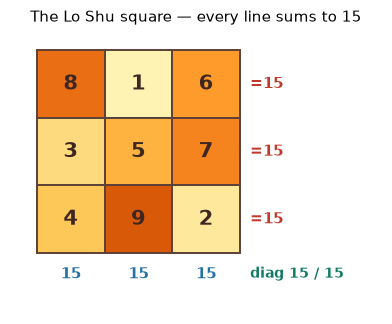

In [1]:
import numpy as np
import matplotlib.pyplot as plt

def siamese(n):
    """de la Loubère (Siamese) construction of an odd-order magic square."""
    assert n % 2 == 1, "de la Loubère works only for odd n"
    M = np.zeros((n, n), dtype=int)
    r, c = 0, n // 2                       # start at the middle of the top row
    for k in range(1, n * n + 1):
        M[r, c] = k
        nr, nc = (r - 1) % n, (c + 1) % n  # try up-and-right, wrapping on the torus
        if M[nr, nc]:                      # collision -> drop straight down instead
            r = (r + 1) % n
        else:
            r, c = nr, nc
    return M

def show_magic(M, ax=None, title=None):
    """Draw a magic square, shading cells by value and annotating every line sum."""
    n = M.shape[0]
    Mc = n * (n * n + 1) // 2
    if ax is None:
        _, ax = plt.subplots(figsize=(4.8, 4.8))
    for i in range(n):
        for j in range(n):
            t = 0.15 + 0.55 * (M[i, j] - 1) / (n * n - 1)
            ax.add_patch(plt.Rectangle((j, n - 1 - i), 1, 1,
                         fc=plt.cm.YlOrBr(t), ec='#5D4037', lw=1.4))
            ax.text(j + .5, n - 1 - i + .5, str(M[i, j]), ha='center', va='center',
                    fontsize=15, fontweight='bold', color='#3E2723')
    for i in range(n):                                  # row sums (right, red)
        ax.text(n + .15, n - 1 - i + .5, f'={M[i].sum()}', ha='left', va='center',
                fontsize=11, color='#C0392B', fontweight='bold')
    for j in range(n):                                  # column sums (below, blue)
        ax.text(j + .5, -.2, f'{M[:, j].sum()}', ha='center', va='top',
                fontsize=11, color='#2471A3', fontweight='bold')
    d1, d2 = int(np.trace(M)), int(np.trace(np.fliplr(M)))
    ax.text(n + .15, -.2, f'diag {d1} / {d2}', ha='left', va='top',
            fontsize=10, color='#117A65', fontweight='bold')
    ax.set_xlim(-.4, n + 2.1); ax.set_ylim(-.9, n + .3)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title or f'Order-{n} magic square  (M = {Mc})', fontsize=11)
    return ax

lo_shu = siamese(3)
print("Lo Shu (de la Loubère, order 3):\n", lo_shu)
print("\nRow sums:      ", lo_shu.sum(1).tolist())
print("Column sums:   ", lo_shu.sum(0).tolist())
print("Diagonal sums: ", int(np.trace(lo_shu)), int(np.trace(np.fliplr(lo_shu))))
show_magic(lo_shu, title='The Lo Shu square — every line sums to 15')
plt.show()


### 2. Decomposing the Numbers — the "Aha!" Moment

Staring at nine numbers at once is hard. So split each one into two independent base-3 pieces:

$$\text{Number} = \underbrace{G}_{\text{Group}\,\in\,\{0,3,6\}} \; + \; \underbrace{U}_{\text{Unit}\,\in\,\{1,2,3\}}.$$

| Number | Group $G$ | Unit $U$ |
|:------:|:---------:|:--------:|
| 1 | 0 | 1 |
| 2 | 0 | 2 |
| 3 | 0 | 3 |
| 4 | 3 | 1 |
| 5 | 3 | 2 |
| 6 | 3 | 3 |
| 7 | 6 | 1 |
| 8 | 6 | 2 |
| 9 | 6 | 3 |

Now imagine $G$ and $U$ as **two separate $3\times3$ grids that we add cell-by-cell**. The magic sum splits cleanly:

- **Grid $G$** places $\{0,3,6\}$ once in every row and column $\;\Rightarrow\;$ every line sums to $0+3+6 = 9$.
- **Grid $U$** places $\{1,2,3\}$ once in every row and column $\;\Rightarrow\;$ every line sums to $1+2+3 = 6$.
- Added together: every line sums to $9 + 6 = 15 = M_3$. **The magic constant factors as $15 = 9 + 6$.**

This is the whole trick: we have **traded one hard problem** (arrange nine distinct numbers) **for two easy, independent ones** (arrange three symbols so each row and column gets one of each — a *Latin square*).


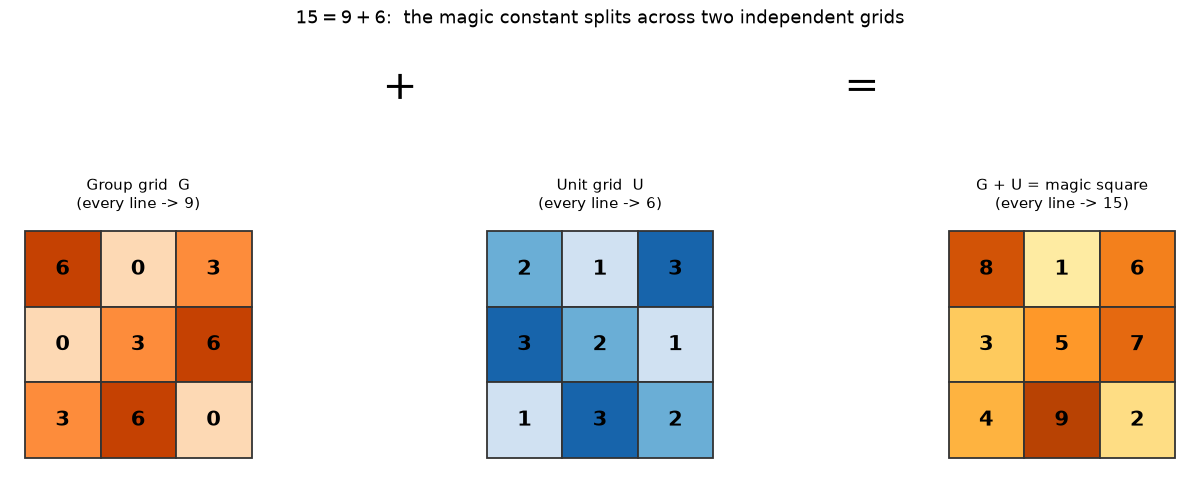

  G: rows=True  cols=True  both diagonals=True  (target 9)
  U: rows=True  cols=True  both diagonals=True  (target 6)
G+U: rows=True  cols=True  both diagonals=True  (target 15)


In [2]:
M = siamese(3)
G = ((M - 1) // 3) * 3      # group value in {0, 3, 6}
U = (M - 1) % 3 + 1         # unit value  in {1, 2, 3}

def grid_plot(ax, A, title, cmap):
    n = A.shape[0]
    lo, hi = int(A.min()), int(A.max())
    for i in range(n):
        for j in range(n):
            t = 0.2 + 0.6 * ((A[i, j] - lo) / (hi - lo) if hi > lo else 0.5)
            ax.add_patch(plt.Rectangle((j, n - 1 - i), 1, 1, fc=cmap(t), ec='#333', lw=1.3))
            ax.text(j + .5, n - 1 - i + .5, str(A[i, j]), ha='center', va='center',
                    fontsize=15, fontweight='bold')
    ax.set_xlim(-.2, n + .2); ax.set_ylim(-.2, n + .2)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(title, fontsize=11)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.6))
grid_plot(axes[0], G,     'Group grid  G\n(every line -> 9)',  plt.cm.Oranges)
grid_plot(axes[1], U,     'Unit grid  U\n(every line -> 6)',   plt.cm.Blues)
grid_plot(axes[2], G + U, 'G + U = magic square\n(every line -> 15)', plt.cm.YlOrBr)
axes[1].annotate('+', xy=(-0.28, 1.5), xycoords='axes fraction', fontsize=30, ha='center', va='center')
axes[2].annotate('=', xy=(-0.28, 1.5), xycoords='axes fraction', fontsize=30, ha='center', va='center')
plt.suptitle(r'$15 = 9 + 6$:  the magic constant splits across two independent grids', y=1.04, fontsize=13)
plt.tight_layout(); plt.show()

for name, A, target in [('G', G, 9), ('U', U, 6), ('G+U', G + U, 15)]:
    rows = np.all(A.sum(1) == target); cols = np.all(A.sum(0) == target)
    diag = (np.trace(A) == target) and (np.trace(np.fliplr(A)) == target)
    print(f"{name:>3}: rows={rows}  cols={cols}  both diagonals={diag}  (target {target})")


### 3. Placing $U$ and $G$ Along Non-Parallel Diagonals

How do you drop three symbols into a $3\times3$ grid so that **every row and column gets exactly one of each**? You lay them along a **diagonal** and let it *wrap around* — think of the grid as a torus (top edge glued to bottom, left glued to right). A wrapped diagonal is called a **broken diagonal**, and it visits each row once and each column once automatically.

- Lay **Grid $U$** $\{1,2,3\}$ along one diagonal direction. Each row and each column then holds one $1$, one $2$, one $3$ $\Rightarrow$ sums to $6$.
- Lay **Grid $G$** $\{0,3,6\}$ along a **different, non-parallel** diagonal direction. Each line holds one $0$, one $3$, one $6$ $\Rightarrow$ sums to $9$.

**Why non-parallel matters.** If the two diagonals ran the *same* way, two different numbers would repeatedly land on the same cells and the pairs $(G, U)$ would collide — some combinations would appear twice and others never. Because the directions are non-parallel, **every one of the nine cells receives a unique $(G, U)$ pair**, so the nine sums $G+U$ reproduce $1,\dots,9$ exactly once. In the language of §1.4, $G$ and $U$ form a pair of **orthogonal Latin squares**.

> **The one subtlety — the diagonals.** Rows and columns are easy; the two *main diagonals* are the extra constraint. Not every pair of non-parallel directions makes the main diagonals sum correctly (a careless choice yields a merely *semi-magic* square whose diagonal misses $15$). De la Loubère's specific choice of directions is exactly the one that also forces both main diagonals of $G$ and of $U$ to carry a full, balanced set — which is why the method below is guaranteed to work.


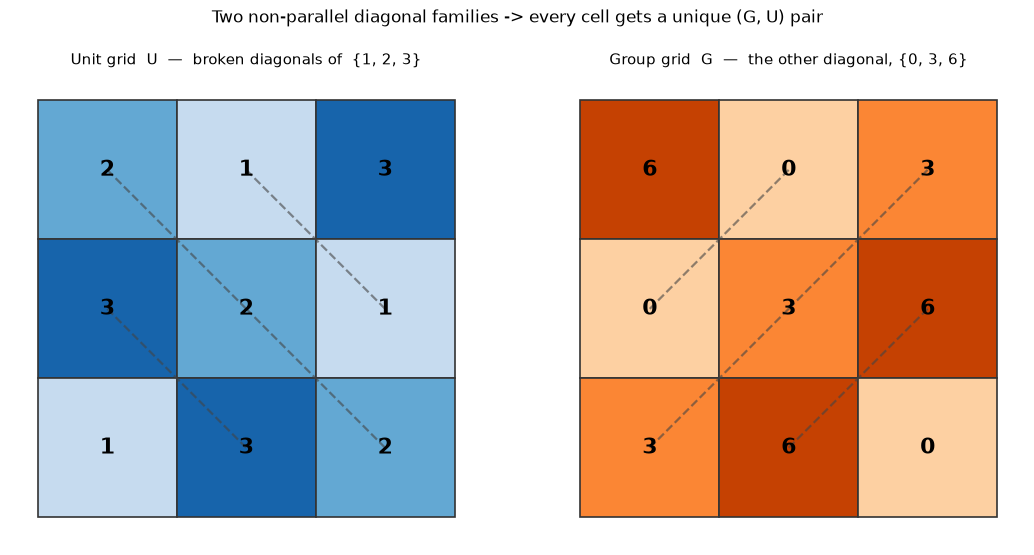

In [3]:
M = siamese(3)
G = ((M - 1) // 3) * 3
U = (M - 1) % 3 + 1
n = 3

fig, axes = plt.subplots(1, 2, figsize=(11, 5.4))
for ax, grid, name, cmap in [
        (axes[0], U, 'Unit grid  U  —  broken diagonals of  {1, 2, 3}', plt.cm.Blues),
        (axes[1], G, 'Group grid  G  —  the other diagonal, {0, 3, 6}', plt.cm.Oranges)]:
    uniq = sorted(set(grid.flatten().tolist()))
    for i in range(n):
        for j in range(n):
            v = int(grid[i, j])
            t = 0.25 + 0.55 * (uniq.index(v) / (len(uniq) - 1))
            ax.add_patch(plt.Rectangle((j, n - 1 - i), 1, 1, fc=cmap(t), ec='#333', lw=1.2))
            ax.text(j + .5, n - 1 - i + .5, str(v), ha='center', va='center',
                    fontsize=16, fontweight='bold')
    # trace each broken diagonal by connecting equal values (wrapping on the torus)
    for v in uniq:
        cells = [(i, j) for i in range(n) for j in range(n) if grid[i, j] == v]
        cells.sort(key=lambda p: p[1])
        for (i1, j1), (i2, j2) in zip(cells, cells[1:]):
            if abs(i1 - i2) <= 1:   # only draw the non-wrapping hop, keeps it readable
                ax.plot([j1 + .5, j2 + .5], [n - 1 - i1 + .5, n - 1 - i2 + .5],
                        color='#444', lw=1.6, ls='--', alpha=.6)
    ax.set_xlim(-.2, n + .2); ax.set_ylim(-.2, n + .2)
    ax.set_aspect('equal'); ax.axis('off')
    ax.set_title(name, fontsize=10.5)

plt.suptitle('Two non-parallel diagonal families -> every cell gets a unique (G, U) pair',
             y=1.02, fontsize=12.5)
plt.tight_layout(); plt.show()


### 4. Why de la Loubère Moves Up-Right, Then Drops Down

De la Loubère's rule (learned in 1687 from Siam) writes $1, 2, \dots, 9$ down **in order**, with no need to build Grids $G$ and $U$ by hand. It is nothing more than *walking the two diagonals simultaneously*:

1. **Up 1, Right 1 (with wrap).** As you count $1 \to 2 \to 3$, you are incrementing the **Unit** $U$. Stepping up-and-right is exactly walking along $U$'s broken diagonal, which spreads $1,2,3$ across distinct rows and columns.

2. **The collision "drop down."** After $3$ you have used every unit $\{1,2,3\}$. To reach $4$ you must add $3$ to the **Group** $G$ ($0 \to 3$). Because $G$ lives on the *other* diagonal, the up-right cell is already occupied — the method detects this **collision** and instead drops straight **down** one cell, which is the single step along $G$'s diagonal. Then the up-right unit-walk resumes.

So the two seemingly arbitrary moves are just the two direction vectors from Step 3:

$$\text{up-right} = \text{increment } U, \qquad \text{drop-down} = \text{increment } G.$$


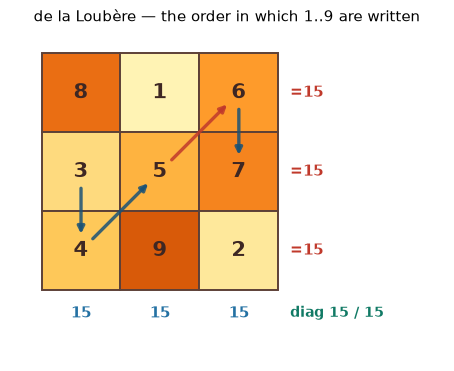

Move-by-move trace (wrap = jumped across an edge of the torus):
  place 1 at (row 0, col 1)  via up-right
  place 2 at (row 2, col 2)  via up-right
  place 3 at (row 1, col 0)  via down
  place 4 at (row 2, col 0)  via up-right
  place 5 at (row 1, col 1)  via up-right
  place 6 at (row 0, col 2)  via down
  place 7 at (row 1, col 2)  via up-right
  place 8 at (row 0, col 0)  via up-right
  place 9 at (row 2, col 1)  via down

Blue arrows = 'up-and-right'  (increment the UNIT u)
Red arrows  = 'drop down'     (unit exhausted -> increment the GROUP g)


In [4]:
n = 3
M = np.zeros((n, n), dtype=int)
path, moves = [], []
r, c = 0, n // 2
for k in range(1, n * n + 1):
    M[r, c] = k
    path.append((r, c))
    nr, nc = (r - 1) % n, (c + 1) % n
    if M[nr, nc]:
        moves.append('down'); r = (r + 1) % n
    else:
        moves.append('up-right'); r, c = nr, nc

fig, ax = plt.subplots(figsize=(5.6, 5.6))
show_magic(M, ax=ax, title='de la Loubère — the order in which 1..9 are written')
center = lambda rc: (rc[1] + 0.5, n - 1 - rc[0] + 0.5)
for (r1, c1), (r2, c2), mv in zip(path, path[1:], moves[1:]):
    if abs(r1 - r2) <= 1 and abs(c1 - c2) <= 1:     # skip torus-wrap hops for clarity
        (x1, y1), (x2, y2) = center((r1, c1)), center((r2, c2))
        col = '#C0392B' if mv == 'down' else '#1A5276'
        ax.annotate('', xy=(x2, y2), xytext=(x1, y1),
                    arrowprops=dict(arrowstyle='-|>', color=col, lw=2.4, alpha=.85,
                                    shrinkA=12, shrinkB=12))
plt.show()

print("Move-by-move trace (wrap = jumped across an edge of the torus):")
for k, ((r, c), mv) in enumerate(zip(path, moves), start=1):
    print(f"  place {k} at (row {r}, col {c})  via {mv}")
print("\nBlue arrows = 'up-and-right'  (increment the UNIT u)")
print("Red arrows  = 'drop down'     (unit exhausted -> increment the GROUP g)")


### 5. Generalization: Any Odd $n$ (Base-$n$ Grids)

Nothing above used the number $3$ except that it was odd. For any odd $n$, decompose each value in base $n$:

$$k - 1 = n \cdot g + u, \qquad g, u \in \{0, 1, \dots, n-1\}.$$

The **group grid** carries the multiples $\{0, n, 2n, \dots, (n-1)n\}$ and the **unit grid** carries $\{0, 1, \dots, n-1\}$; each is a Latin square laid along its own broken diagonal, and de la Loubère walks both at once. The magic constant is

$$M_n = \frac{n(n^2+1)}{2}, \qquad\text{so}\qquad M_5 = \frac{5\cdot 26}{2} = 65, \quad M_7 = \frac{7\cdot 50}{2} = 175.$$

**Summary of first principles**

- **Decomposition.** Every $k \in \{1, \dots, n^2\}$ gets two orthogonal coordinates, $k = n\,g + u$.
- **Orthogonal trajectories.** Two non-parallel direction vectors on a torus: one increments $u$, the collision vector increments $g$.
- **Symmetry.** Because the vectors are non-parallel and wrap uniformly, every row and column receives a *complete* set of unit values and a complete set of group values — so every line hits $M_n$.

*(This construction is for **odd** $n$. Singly-even $n$ like $6$ and doubly-even $n$ like $4, 8$ need different methods — LUX and the crossed-diagonal complement trick — outside our first-principles thread here.)*


n=3:  M_3 = n(n^2+1)/2 = 15   rows=True cols=True diagonals=True uses 1..9=True
n=5:  M_5 = n(n^2+1)/2 = 65   rows=True cols=True diagonals=True uses 1..25=True
n=7:  M_7 = n(n^2+1)/2 = 175   rows=True cols=True diagonals=True uses 1..49=True


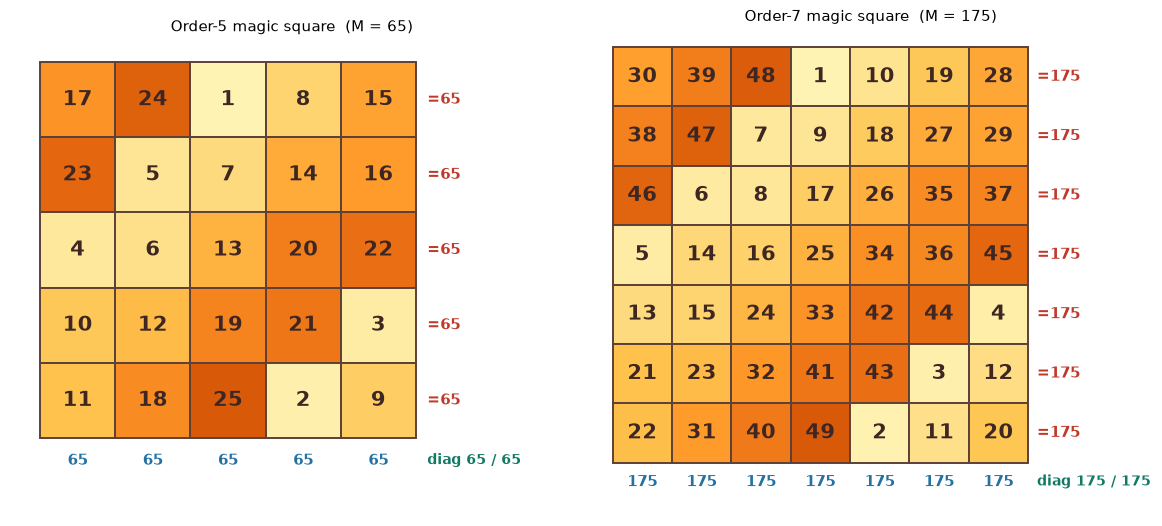

In [5]:
for n in (3, 5, 7):
    M = siamese(n)
    Mc = n * (n * n + 1) // 2
    rows_ok = bool(np.all(M.sum(1) == Mc))
    cols_ok = bool(np.all(M.sum(0) == Mc))
    diag_ok = bool(np.trace(M) == Mc and np.trace(np.fliplr(M)) == Mc)
    perm_ok = sorted(M.flatten().tolist()) == list(range(1, n * n + 1))
    print(f"n={n}:  M_{n} = n(n^2+1)/2 = {Mc}   "
          f"rows={rows_ok} cols={cols_ok} diagonals={diag_ok} uses 1..{n*n}={perm_ok}")

fig, axes = plt.subplots(1, 2, figsize=(12, 5.4))
show_magic(siamese(5), ax=axes[0], title='Order-5 magic square  (M = 65)')
show_magic(siamese(7), ax=axes[1], title='Order-7 magic square  (M = 175)')
plt.tight_layout(); plt.show()


### 6. The Algebra Underneath: Triangular Numbers, Squares, and Cubes

Everything above rested on one sum: $1 + 2 + \cdots + m$. That is the **$m$-th triangular number**

$$T_m = 1 + 2 + \cdots + m = \frac{m(m+1)}{2},$$

and the grand total that fixed the magic constant was exactly $T_{n^2} = \tfrac{n^2(n^2+1)}{2}$.

**Scaling a triangular number by $n$.** A companion identity worth having in hand:

$$n \cdot T_n \;=\; n\cdot\frac{n(n+1)}{2} \;=\; \frac{n^2(n+1)}{2} \;=\; \tfrac12 n^3 + \tfrac12 n^2, \qquad\text{factored: } \frac{n^2(n+1)}{2}.$$

| $n$ | $T_n = \tfrac{n(n+1)}{2}$ | $n\,T_n = \tfrac{n^2(n+1)}{2}$ |
|:--:|:--:|:--:|
| 1 | 1 | 1 |
| 2 | 3 | 6 |
| 3 | 6 | 18 |
| 4 | 10 | 40 |
| 5 | 15 | 75 |
| 6 | 21 | 126 |
| 7 | 28 | 196 |
| 8 | 36 | 288 |
| 9 | 45 | 405 |
| 10 | 55 | 550 |

**The natural next questions — squares and cubes.** Once you know the *first powers* sum to a triangular number, you ask about higher powers:

$$\sum_{k=1}^{n} k^2 = \frac{n(n+1)(2n+1)}{6}, \qquad\qquad \sum_{k=1}^{n} k^3 = \left(\frac{n(n+1)}{2}\right)^{2} = T_n^{\,2}.$$

That second identity is **Nicomachus's theorem**: *the sum of the first $n$ cubes equals the square of the $n$-th triangular number.* So the humble triangle that dictated the magic constant reappears — squared — as the sum of cubes. The cell below verifies all three closed forms.


All closed forms verified for n = 1..10.

  n   T_n   n.T_n  Sum k^2  Sum k^3   T_n^2
  1     1       1        1        1       1
  2     3       6        5        9       9
  3     6      18       14       36      36
  4    10      40       30      100     100
  5    15      75       55      225     225
  6    21     126       91      441     441
  7    28     196      140      784     784
  8    36     288      204     1296    1296
  9    45     405      285     2025    2025
 10    55     550      385     3025    3025


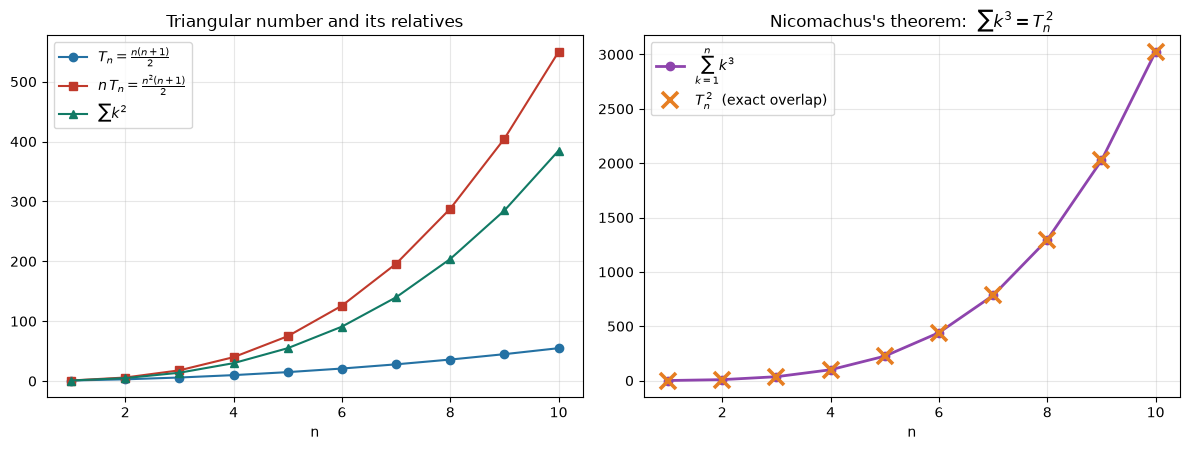

In [6]:
n_max = 10
n = np.arange(1, n_max + 1)

T        = n * (n + 1) // 2      # triangular number  T_n
n_Tn     = n * T                 # n * T_n = n^2 (n+1) / 2
sq_sum   = np.cumsum(n**2)       # 1^2 + ... + n^2
cube_sum = np.cumsum(n**3)       # 1^3 + ... + n^3

# verify each closed form against the running sum
assert np.array_equal(T,        n * (n + 1) // 2)
assert np.array_equal(n_Tn,     n**2 * (n + 1) // 2)
assert np.array_equal(sq_sum,   n * (n + 1) * (2 * n + 1) // 6)
assert np.array_equal(cube_sum, T**2)            # Nicomachus:  sum k^3 = T_n^2
print("All closed forms verified for n = 1..10.\n")

print(f"{'n':>3}{'T_n':>6}{'n.T_n':>8}{'Sum k^2':>9}{'Sum k^3':>9}{'T_n^2':>8}")
for i in range(n_max):
    print(f"{n[i]:>3}{T[i]:>6}{n_Tn[i]:>8}{sq_sum[i]:>9}{cube_sum[i]:>9}{T[i]**2:>8}")

fig, ax = plt.subplots(1, 2, figsize=(12, 4.6))
ax[0].plot(n, T,      'o-', color='#2471A3', label=r'$T_n=\frac{n(n+1)}{2}$')
ax[0].plot(n, n_Tn,   's-', color='#C0392B', label=r'$n\,T_n=\frac{n^2(n+1)}{2}$')
ax[0].plot(n, sq_sum, '^-', color='#117A65', label=r'$\sum k^2$')
ax[0].set_title('Triangular number and its relatives'); ax[0].set_xlabel('n')
ax[0].legend(); ax[0].grid(alpha=.3)

ax[1].plot(n, cube_sum, 'o-', color='#8E44AD', lw=2, label=r'$\sum_{k=1}^{n} k^3$')
ax[1].plot(n, T**2, 'x', ms=12, mew=2.6, color='#E67E22', label=r'$T_n^{\,2}$  (exact overlap)')
ax[1].set_title("Nicomachus's theorem:  $\\sum k^3 = T_n^{\\,2}$")
ax[1].set_xlabel('n'); ax[1].legend(); ax[1].grid(alpha=.3)
plt.tight_layout(); plt.show()
